# CNN Classifier

In [2]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import kagglehub
import matplotlib.pyplot as plt
from tqdm import tqdm

### Download Dataset
* link: https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset

In [3]:
path = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Create Dataset loader

In [ ]:
transform_no_norm = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=f'{path}/Aerial_Landscapes', transform=transform_no_norm)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

mean = torch.zeros(3)
std = torch.zeros(3)
total_pixels = 0

for images, _ in loader:
    batch_samples = images.size(0)  # num of images per batch
    height, width = images.size(2), images.size(3) 
    num_pixels = batch_samples * height * width 
    
    mean += images.mean(dim=[0, 2, 3]) * num_pixels  # Weighted sum
    std += images.pow(2).mean(dim=[0, 2, 3]) * num_pixels  # Accumulate squared mean for std calculation
    total_pixels += num_pixels  # Accumulate total pixels

mean /= total_pixels  # Compute final mean
std = torch.sqrt(std / total_pixels - mean**2)  # Compute std using variance formula

print(f"Computed Mean: {mean.tolist()}")
print(f"Computed Std: {std.tolist()}")

transform_with_norm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()) 
])

dataset = datasets.ImageFolder(root=f'{path}/Aerial_Landscapes', transform=transform_with_norm)

class_indices = {}

for i in range(len(dataset)):
    _,label = dataset[i]
    if label not in class_indices:
        class_indices[label] = []
    class_indices[label].append(i)

train_indices = []
val_indices = []
test_indices = []

for label in class_indices:
    indices = class_indices[label]
    
    train_split = int(len(indices) * 0.7)
    val_split = int(len(indices) * 0.85)
    test_split = int(len(indices) * 1.0)
    
    train_indices.extend(indices[:train_split])
    val_indices.extend(indices[train_split:val_split])
    test_indices.extend(indices[val_split:test_split])

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)


Computed Mean: [0.37805402278900146, 0.3930436074733734, 0.3444664180278778]
Computed Std: [0.21396854519844055, 0.18421611189842224, 0.17789648473262787]


### Dataloader

In [5]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Model

In [6]:
class ClassifierModel(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        
        self.bn0 = nn.BatchNorm2d(3)  # Batch normalization for input data
        
        # Layer 1: Stacked convolutions
        self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(8)
        self.conv1_2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=5, padding=2)
        self.bn1_2 = nn.BatchNorm2d(8)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        # Layer 2: Stacked convolutions
        self.conv2_1 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(8)
        self.conv2_2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(8)
        
        self.conv3 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)
        
        self.conv4 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        
        self.conv5 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(p=0.5)
        
        self.fc2 = nn.Linear(128, 64)
        self.bn_fc2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(p=0.5)
        
        self.fc3 = nn.Linear(64, 32)
        self.bn_fc3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(p=0.5)
        
        self.fc4 = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.bn0(x)  # Normalize input data
        
        # Layer 1: Stacked convolutions
        x = self.conv1_1(x)
        x = self.relu(x)
        x = self.bn1_1(x)
        x = self.conv1_2(x)
        x = self.relu(x)
        x = self.bn1_2(x)
        x = self.pool(x)  # 256x256 -> 128x128
        
        # Layer 2: Stacked convolutions
        x = self.conv2_1(x)
        x = self.relu(x)
        x = self.bn2_1(x)
        x = self.conv2_2(x)
        x = self.relu(x)
        x = self.bn2_2(x)
        x = self.pool(x)  # 128x128 -> 64x64
        
        x = self.conv3(x)
        x = self.relu(x)
        x = self.bn3(x)
        x = self.pool(x)  # 64x64 -> 32x32
        
        x = self.conv4(x)
        x = self.relu(x)
        x = self.bn4(x)
        x = self.pool(x)  # 32x32 -> 16x16
        
        x = self.conv5(x)
        x = self.relu(x)
        x = self.bn5(x)
        x = self.pool(x)  # 16x16 -> 8x8

        # Fully connected layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn_fc1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.bn_fc2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.relu(x)
        x = self.bn_fc3(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        
        return x

In [7]:
model = ClassifierModel().to(device)

lr = 0.0005
optimizer = torch.optim.Adam(params=model.parameters(),lr=lr)
loss_fn = nn.functional.cross_entropy

In [8]:
def plot_loss_curve(train_loss, val_loss):
    # Plot Train Loss
    plt.plot(train_loss, label="Train Loss", color='blue')
    plt.title("Train Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Plot Validation Loss
    plt.plot(val_loss, label="Validation Loss", color='red')
    plt.title("Validation Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Train

Epoch 1 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.02batch/s]


New best state found!
Epoch 2 running!


Validation: 100%|██████████| 15/15 [00:04<00:00,  3.63batch/s]


New best state found!
Epoch 3 running!


...

New best state found!
Epoch 4 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.83batch/s]


New best state found!
Epoch 5 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.82batch/s]

New best state found!


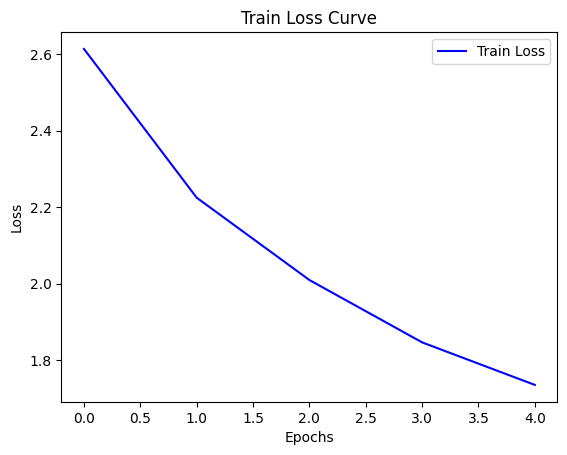

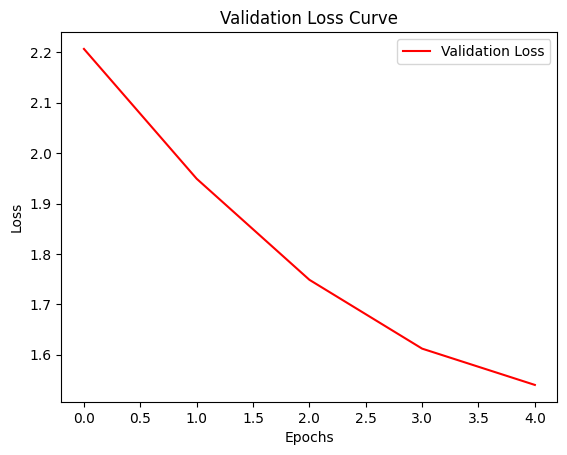

Epoch 6 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.99batch/s]


New best state found!
Epoch 7 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.92batch/s]


New best state found!
Epoch 8 running!


...

New best state found!
Epoch 9 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.81batch/s]


patience: 1/6
Epoch 10 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.03batch/s]

New best state found!


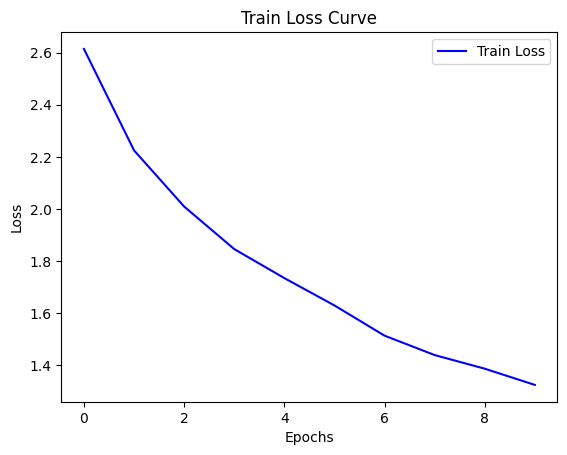

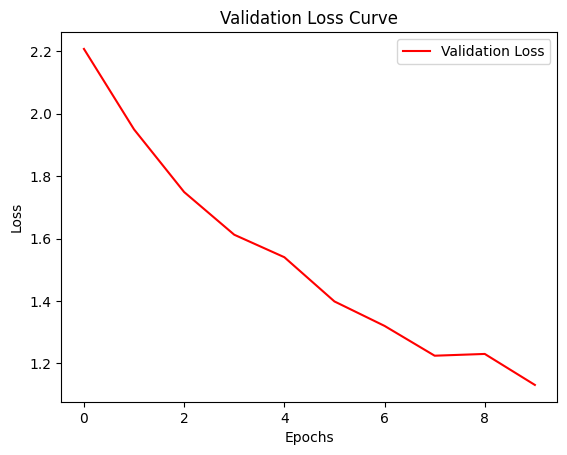

Epoch 11 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.91batch/s]


New best state found!
Epoch 12 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.88batch/s]


patience: 1/6
Epoch 13 running!


...

New best state found!
Epoch 14 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.82batch/s]


patience: 1/6
Epoch 15 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.82batch/s]

New best state found!


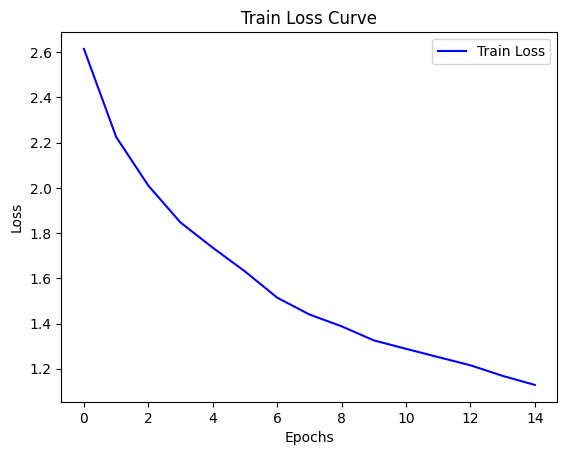

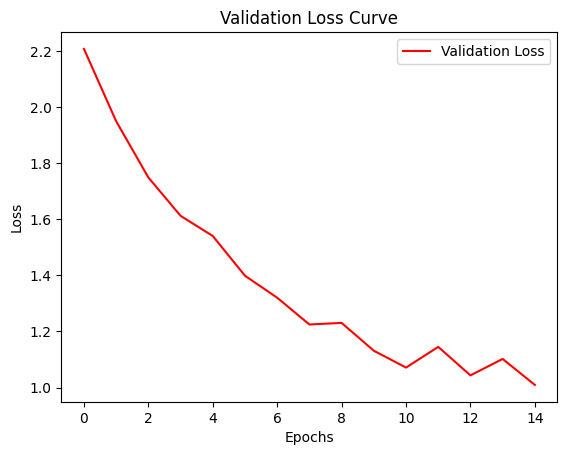

Epoch 16 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.97batch/s]


patience: 1/6
Epoch 17 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.94batch/s]


New best state found!
Epoch 18 running!


...

New best state found!
Epoch 19 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.89batch/s]


New best state found!
Epoch 20 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.92batch/s]

New best state found!


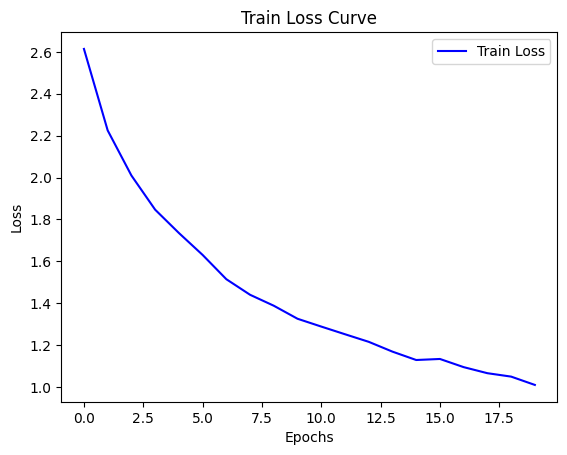

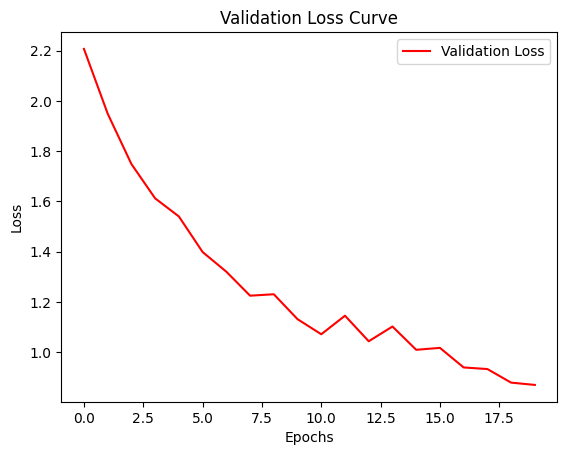

Epoch 21 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.88batch/s]


New best state found!
Epoch 22 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.01batch/s]


patience: 1/6
Epoch 23 running!


...

patience: 2/6
Epoch 24 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.93batch/s]


New best state found!
Epoch 25 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.04batch/s]

patience: 1/6


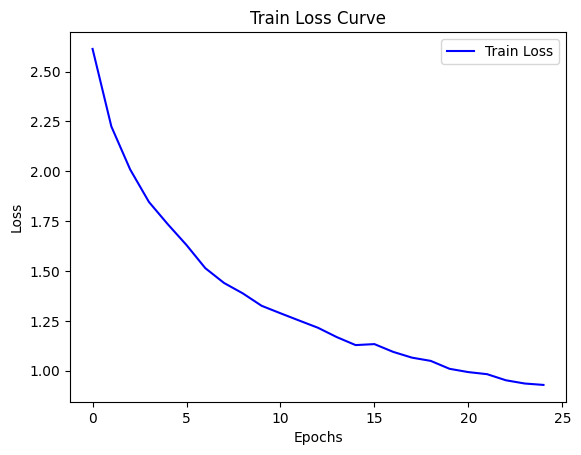

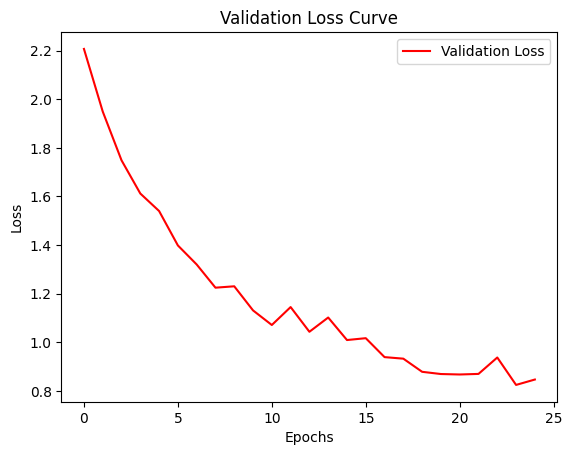

Epoch 26 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.00batch/s]


New best state found!
Epoch 27 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.00batch/s]


patience: 1/6
Epoch 28 running!


...

New best state found!
Epoch 29 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.84batch/s]


patience: 1/6
Epoch 30 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.03batch/s]

patience: 2/6


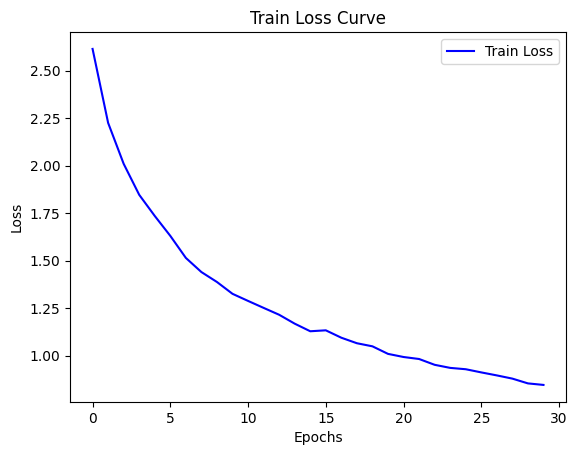

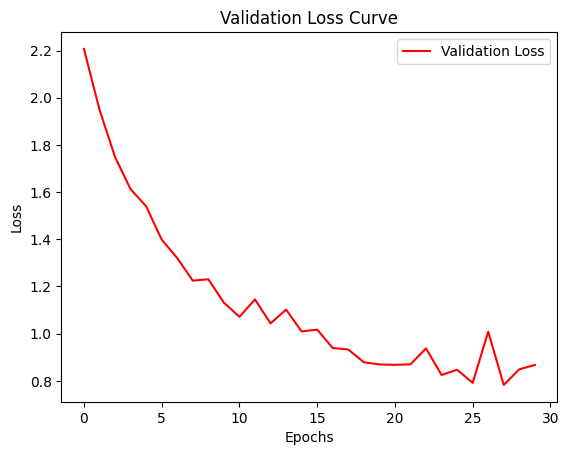

Epoch 31 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.95batch/s]


patience: 3/6
Epoch 32 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.07batch/s]


patience: 4/6
Epoch 33 running!


...

New best state found!
Epoch 34 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.93batch/s]


New best state found!
Epoch 35 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.09batch/s]

patience: 1/6


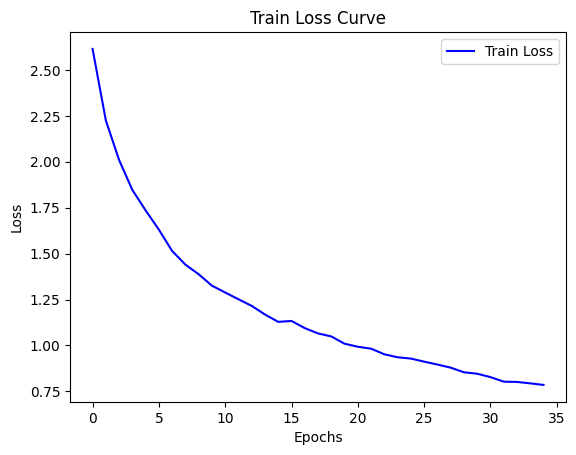

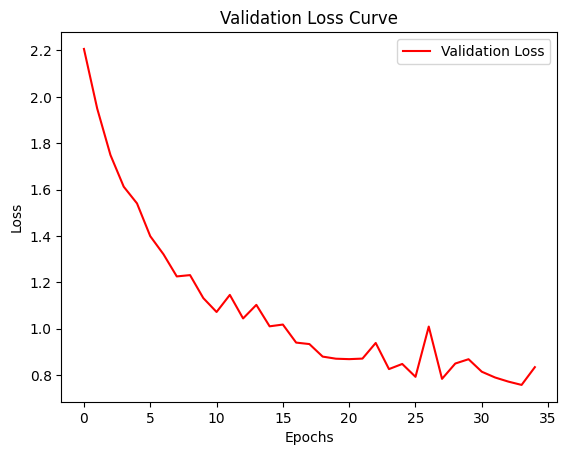

Epoch 36 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.96batch/s]


New best state found!
Epoch 37 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.07batch/s]


patience: 1/6
Epoch 38 running!


...

patience: 2/6
Epoch 39 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.98batch/s]


patience: 3/6
Epoch 40 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.88batch/s]

patience: 4/6


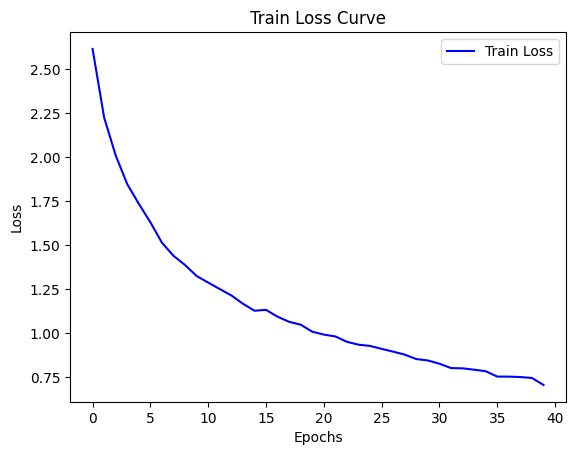

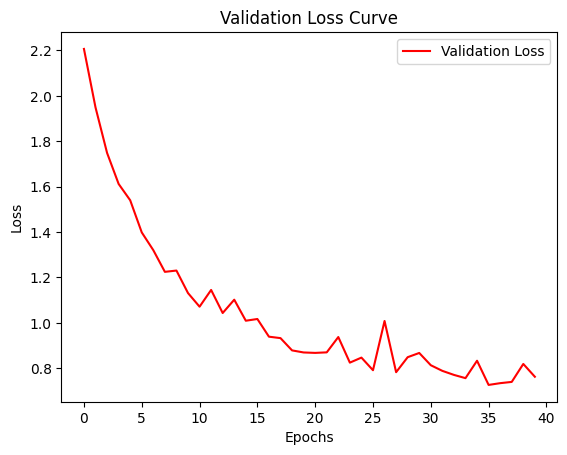

Epoch 41 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.88batch/s]


New best state found!
Epoch 42 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.93batch/s]


patience: 1/6
Epoch 43 running!


...

patience: 2/6
Epoch 44 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.98batch/s]


patience: 3/6
Epoch 45 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  3.98batch/s]

patience: 4/6


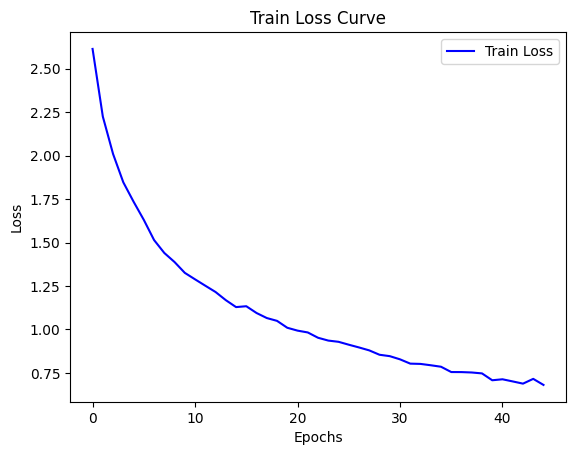

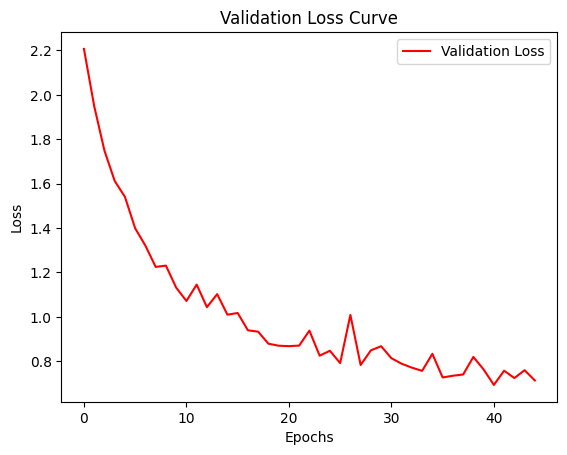

Epoch 46 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.21batch/s]


patience: 5/6
Epoch 47 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.20batch/s]


patience: 6/6
Epoch 48 running!


Validation: 100%|██████████| 15/15 [00:03<00:00,  4.09batch/s]

patience: 7/6
No improvement seen!


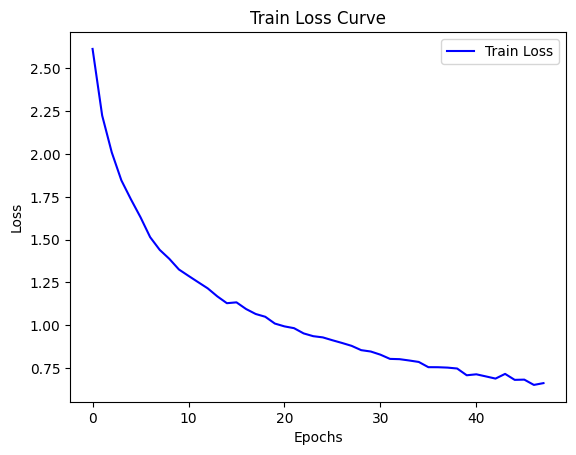

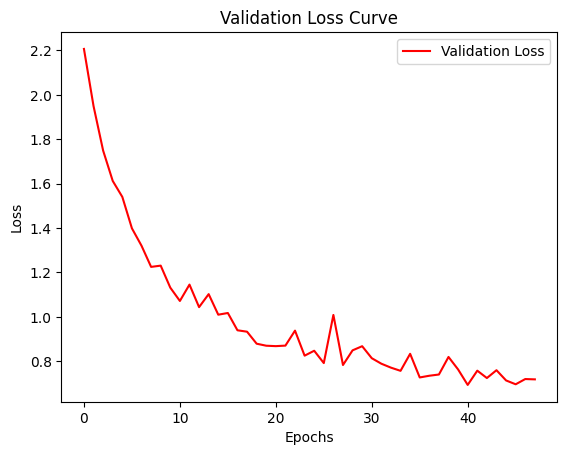

In [9]:
epochs = 60

train_loss = []
val_loss = []

# Earling stopping simple approach
patience = 6
best_val_loss = float('inf')
curr_val_loss = 0.0
no_improve_counter = 0
best_model_state = None

for i in range(epochs):
    print(f"Epoch {i+1} running!")
    train_epoch_loss = 0.0
    train_epoch_loss_cnt = 0
    val_epoch_loss = 0.0
    val_epoch_loss_cnt = 0
    
    model.train()
    for X,t in tqdm(train_loader, unit="batch",desc="Training"):
        X,t = X.to(device),t.to(device)
        
        optimizer.zero_grad()
        
        y = model(X)
        loss = loss_fn(y,t)
        
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
        train_epoch_loss_cnt += 1
    train_loss.append(train_epoch_loss/train_epoch_loss_cnt)
    
    model.eval()
    with torch.no_grad():
        for X,t in tqdm(val_loader, unit="batch",desc="Validation"):
            X,t = X.to(device),t.to(device)
            y = model(X)
            loss = loss_fn(y,t)
            val_epoch_loss += loss.item()
            val_epoch_loss_cnt += 1
        curr_val_loss = val_epoch_loss/val_epoch_loss_cnt
        val_loss.append(curr_val_loss)
        
    if curr_val_loss < best_val_loss:
        best_val_loss = curr_val_loss
        best_model_state = model.state_dict().copy()
        no_improve_counter = 0
        print("New best state found!")
    else:
        no_improve_counter += 1
        print(f"patience: {no_improve_counter}/{patience}")
        if no_improve_counter > patience:
            print("No improvement seen!")
            break
    
    if (i+1)%5 == 0:
        plot_loss_curve(train_loss, val_loss)

if best_model_state is not None:
    model.load_state_dict(best_model_state)

plot_loss_curve(train_loss, val_loss)

### Test

In [10]:
model.eval()

# Test accuracy calculation
test_correct = 0
test_total = 0
with torch.no_grad():
    for X, t in tqdm(test_loader, unit="batch", desc="Testing"):
        X, t = X.to(device), t.to(device)
        y = model(X)
        
        # Get predictions from the highest value
        predicted = torch.argmax(y, dim=1)
        
        # Count correct predictions
        test_correct += (predicted == t).sum().item()
        test_total += t.size(0)

test_accuracy = (test_correct / test_total) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Train accuracy calculation
train_correct = 0
train_total = 0
with torch.no_grad():
    for X, t in tqdm(train_loader, unit="batch", desc="Evaluating Train"):
        X, t = X.to(device), t.to(device)
        y = model(X)
        
        predicted = torch.argmax(y, dim=1)
        train_correct += (predicted == t).sum().item()
        train_total += t.size(0)

train_accuracy = (train_correct / train_total) * 100
print(f"Train Accuracy: {train_accuracy:.2f}%")
        

Testing: 100%|██████████| 1800/1800 [00:05<00:00, 354.33batch/s]


Test Accuracy: 81.17%


Evaluating Train: 100%|██████████| 66/66 [00:17<00:00,  3.71batch/s]

Train Accuracy: 88.25%
